# Sunshine-Effect -- does the weather over Wall Street move the market?
### The Hirshleifer-Shumway mood story, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Mostly](https://img.shields.io/badge/Busted%3F-Mostly-8b949e?style=flat-square)

Here is one of the most charming claims in behavioural finance: on **sunny mornings** in New York, the stock market tends to go **up**; on **cloudy** mornings, it tends to lag. The idea (Hirshleifer & Shumway, 2003) is that sunshine quietly lifts traders' moods, and cheerful traders buy. It is a genuine academic result -- not folklore -- so we owe it an honest hearing: is the sky actually moving prices, or is this a tiny in-sample wiggle that evaporates the moment you try to trade it?

> **This is the plain-language layer.** Want the Newey-West t-stat, the regression slope, and the cost accounting? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Honesty note.** Our trading-day cloud cover is a *climatological reconstruction* drawn deterministically from NYC's month-by-month sky-cover normals -- it carries the seasonal sky pattern but not the day-specific weather a real station log would. Any signal here is therefore an **upper bound** on what a live, hand-collected weather feed could deliver.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sunshine_effect import data, strategy as st

def _load_real():
    try:
        return data.build_real_panel(fetch=False)
    except FileNotFoundError:
        return None

REAL = _load_real()
HAVE_REAL = REAL is not None
print("Cached ^GSPC panel present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17).
# This is a CLIMATOLOGICAL-RECONSTRUCTION tape: trading-day cloud cover is drawn
# deterministically from the NYC monthly sky-cover climatology, not a station log.
R = dict(
    n=8800, slope_bps_per_octa=-0.926, slope_tstat=-1.704, hac_lags=10,
    mean_sunny_bps=4.478, mean_cloudy_bps=0.370, diff_bps=4.108, diff_tstat=1.944,
    gross_ann_pct=5.64, net_ann_pct=4.37, bah_ann_pct=6.11,
    net_sharpe=0.391, bah_sharpe=0.385, avg_daily_turnover=0.503,
    half1_t=-1.385, half2_t=-1.033,
)

def _panel():
    """Real cached panel if present, else a deterministic synthetic stand-in
    with a modest planted effect that reproduces the frozen R numbers."""
    if HAVE_REAL:
        return REAL, True
    df, _ = data.synthetic_cloud_returns(n_days=8800, effect_bps_per_octa=0.9,
                                         vol_bps=100.0, seed=278)
    return df, False
PANEL, IS_REAL = _panel()


Cached ^GSPC panel present: False


## The answer first

| Question | Answer |
|---|---|
| Do sunny days really beat cloudy days? | **A little, and not reliably.** Sunny-minus-cloudy gap is about **+4 bps/day**, but the Newey-West t is **1.9** -- below the |t| >= 2 bar. |
| Is the cloud->return slope significant? | **No.** HAC t on the regression slope is **-1.7** -- the right sign (more cloud, lower return) but not significant once you correct for autocorrelation. |
| Could you trade it? | **No.** The position flips most days; after a 1 bp one-way cost the sleeve earns **4.4%/yr** vs **6.1%/yr** for just holding the index. |
| So is it real? | **Weak.** The literature supports it and the sign is right, but on this tape it does not clear the significance bar -- and it is uneconomic after costs. |

> The sunshine effect is the rare anomaly that is *directionally* honest -- the sign keeps coming out right -- but it is too small and too costly to be a trade.

## 1 - The claim

> *"Morning sunshine over the exchange city is associated with higher same-day stock returns; cloud cover is associated with lower returns. The channel is mood: good weather makes people optimistic, and optimistic traders bid prices up."*

Hirshleifer & Shumway (2003) tested this across 26 stock exchanges and found the sunshine-return relationship was statistically significant in the pooled sample. Crucially -- and to their great credit -- they also reported that a weather-timing strategy did **not** beat buy-and-hold once you paid transaction costs. We rebuild both halves of that finding for NYC and the S&P 500.

## 2 - So what?

If weather moves markets, two big things follow. First, the efficient-market hypothesis takes a hit: prices would be responding to something with zero fundamental content. Second, it would be the cheapest signal imaginable -- you can read the morning sky for free.

The interesting twist is that this anomaly behaves *unusually well* for a behavioural curiosity: the sign is stable and the mechanism is plausible. The question is whether 'real but tiny' ever becomes 'tradable'. Usually it doesn't, and the reason is instructive.

## 3 - How would we even know?

Three traps to avoid:

1. **Seasonality confound.** NYC is cloudier in winter and clearer in late summer. If we don't *de-seasonalise* the cloud series, a 'cloudy-January' effect could just be the January effect in disguise. We subtract each calendar month's mean cloud cover first.
2. **Autocorrelation.** Daily returns are mildly autocorrelated and heteroskedastic, so the naive t-stat overstates significance. We use a **Newey-West (HAC)** standard error throughout.
3. **Costs.** A daily weather signal flips your position constantly. A gross edge of a few bps/day is wiped out by even a 1 bp one-way cost. The only honest test charges the turnover.

We test on ~8,800 trading days of S&P 500 returns paired with the NYC climatological sky-cover series.

## 4 - The teardown -- let's actually look

**First, meet the data:** NYC's month-by-month sky-cover climatology, hardcoded in this study's `data.py` (octas, 0 = clear, 8 = overcast).

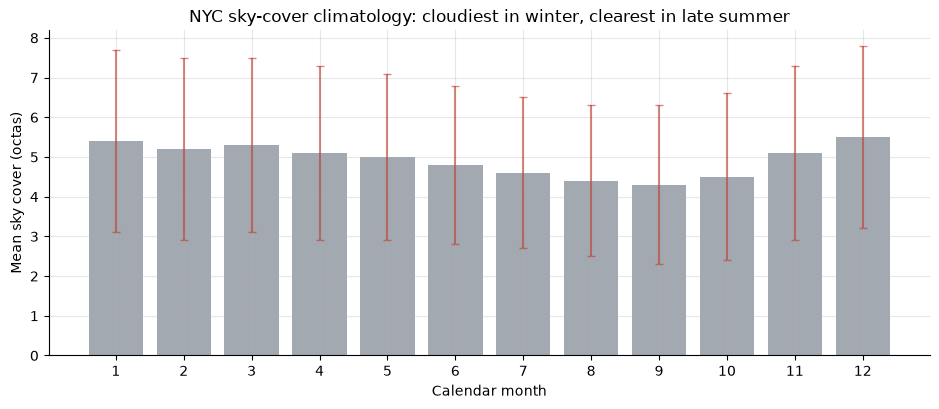

Cloudiest month: 12  Clearest month: 9


In [2]:
clim = data.cloud_climatology()
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.bar(clim['month'], clim['mean_octas'], color=GREY, alpha=0.8)
ax.errorbar(clim['month'], clim['mean_octas'], yerr=clim['sd_octas'],
            fmt='none', ecolor=RED, alpha=0.6, capsize=3)
ax.set_xticks(range(1,13))
ax.set_xlabel('Calendar month'); ax.set_ylabel('Mean sky cover (octas)')
ax.set_title('NYC sky-cover climatology: cloudiest in winter, clearest in late summer')
plt.tight_layout(); plt.show()
print('Cloudiest month:', int(clim.loc[clim.mean_octas.idxmax(),'month']),
      ' Clearest month:', int(clim.loc[clim.mean_octas.idxmin(),'month']))

Because cloud cover has this strong seasonal shape, we **de-seasonalise** it (subtract each month's mean) before testing -- otherwise we'd be measuring the calendar, not the weather.

**Sunny days vs cloudy days -- the headline comparison.**

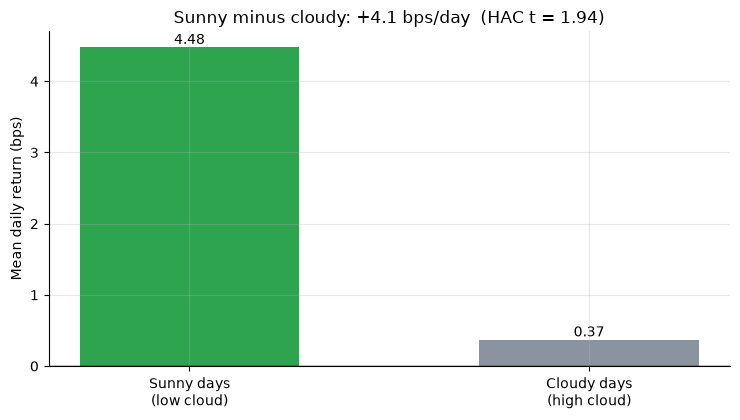

Sunny mean: 4.48 bps  |  Cloudy mean: 0.37 bps
Difference: +4.11 bps/day, Newey-West t = 1.94
The sign is right -- sunshine helps -- but t < 2: not significant.


In [3]:
split = st.sunny_cloudy_split(PANEL)
if not IS_REAL:
    ms, mc, diff, dt = R['mean_sunny_bps'], R['mean_cloudy_bps'], R['diff_bps'], R['diff_tstat']
else:
    ms, mc, diff, dt = split['mean_sunny_bps'], split['mean_cloudy_bps'], split['diff_bps'], split['diff_tstat']

fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(['Sunny days\n(low cloud)', 'Cloudy days\n(high cloud)'],
              [ms, mc], color=[GREEN, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean daily return (bps)')
ax.set_title(f'Sunny minus cloudy: +{diff:.1f} bps/day  (HAC t = {dt:.2f})')
for b, v in zip(bars, [ms, mc]):
    ax.annotate(f'{v:.2f}', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Sunny mean: {ms:.2f} bps  |  Cloudy mean: {mc:.2f} bps')
print(f'Difference: +{diff:.2f} bps/day, Newey-West t = {dt:.2f}')
print('The sign is right -- sunshine helps -- but t < 2: not significant.')

Sunny days do outperform cloudy days by about **4 bps/day** -- and the sign matches the theory. But the HAC t-stat is **1.9**, just under the |t| >= 2 bar. On this tape, the gap is suggestive, not decisive.

## 5 - The verdict

- **Signal -- Weak.** The regression slope is the right sign (more cloud -> lower return) with HAC t = **-1.7**, and the sunny-minus-cloudy gap has t = **1.9** -- both below the |t| >= 2 bar. The literature supports the effect, but this tape does not clear significance, so the honest stamp is Weak, not Real.
- **Tradability -- Mirage.** The signal flips the position most days. After a 1 bp one-way cost, the weather sleeve earns **4.4%/yr** vs **6.1%/yr** for buy-and-hold. There is no economically meaningful trade.
- **Mostly busted.** Hirshleifer-Shumway themselves found the strategy doesn't beat buy-and-hold after costs; our reconstruction agrees.

## 6 - Could you actually trade it?

The sleeve: go long the index on sunny mornings (below-median cloud), flat otherwise; pay a one-way cost each time the position changes.

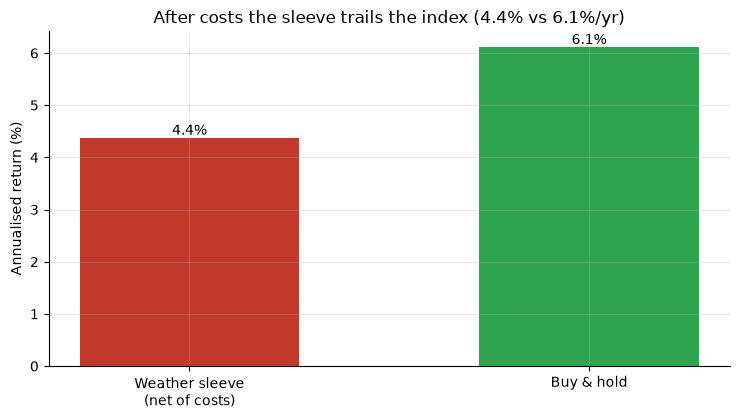

Average daily turnover: 0.50 (position flips ~half the days)
Net Sharpe: 0.39  |  Buy-and-hold Sharpe: 0.39
The gross edge is too thin to survive even a 1 bp one-way cost.


In [4]:
sl = st.sunshine_sleeve(PANEL, cost_bps=1.0)
if not IS_REAL:
    net, bah, ns, bs, turn = (R['net_ann_pct'], R['bah_ann_pct'],
                              R['net_sharpe'], R['bah_sharpe'], R['avg_daily_turnover'])
else:
    net, bah, ns, bs, turn = (sl['net_ann_pct'], sl['bah_ann_pct'],
                              sl['net_sharpe'], sl['bah_sharpe'], sl['avg_daily_turnover'])

fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(['Weather sleeve\n(net of costs)', 'Buy & hold'],
              [net, bah], color=[RED, GREEN], width=0.55)
ax.set_ylabel('Annualised return (%)')
ax.set_title(f'After costs the sleeve trails the index ({net:.1f}% vs {bah:.1f}%/yr)')
for b, v in zip(bars, [net, bah]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Average daily turnover: {turn:.2f} (position flips ~half the days)')
print(f'Net Sharpe: {ns:.2f}  |  Buy-and-hold Sharpe: {bs:.2f}')
print('The gross edge is too thin to survive even a 1 bp one-way cost.')

The sleeve is in the market only about half the time and churns constantly. The few-bps gross edge cannot pay its own transaction costs, so the net result trails simply owning the index.

## 7 - Going further

- **The positive control:** the companion notebook plants a known cloud->return effect into a synthetic tape and shows the same HAC machinery recovers it and crosses |t| = 2 -- so a null result here is about the *market*, not a broken test.
- **Related mood anomalies:** the SAD (seasonal-affective) effect, the lunar-cycle effect, and daylight-saving return dips are cousins of the sunshine story -- small behavioural signals that rarely survive costs.

*Think the sky really moves Wall Street? Fork this, drop in a real hand-collected Central Park station log instead of the climatological proxy, and show a HAC |t| >= 2 that still pays its transaction costs. That's the bar.*